In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, spectrogram
from TIF import RawSignal, Info, Anotaciones

In [146]:
class EMGSignal(RawSignal):
    def __init__(self, data:np.ndarray, sfreq:float, info:Info=None, anotaciones:Anotaciones=None, first_samp: int = 0, umbral_microv=50):
        """
        Clase para representar una señal de electromiografía (EMG).

        Args:
            data : Array 2D con la señal EMG. Forma: (n_canales, n_muestras)
            sfreq : Frecuencia de muestreo en Hz.
            umbral_microv : Umbral de detección de activación en microvoltios (por defecto 50).

        """

        data = data if data.ndim == 2 else data[np.newaxis, :]

        super().__init__(data, sfreq, info, anotaciones, first_samp)

        self.umbral = umbral_microv

        self.activaciones = self.detectar_activaciones()

    def detectar_activaciones(self):
        """
        Detecta eventos de activación muscular en la señal EMG basados en un umbral.

        Recorre cada canal de la señal EMG y determina los índices de muestra 
        en los que la amplitud de la señal supera el umbral especificado (en microvoltios). 
        Se considera que en esos puntos ocurre una activación muscular.

        Returns:
            activaciones : lista de arrays.
                Para cada canal, contiene un array con los índices de muestra
                donde se detectó una activación 
        """
        activaciones = []

        for canal in range(self.data.shape[0]):
            canal_data = self.data[canal]
            indices = np.where(canal_data > self.umbral)[0]
            activaciones.append(indices)

        return activaciones

    def plot_activaciones(self, canal=None, start_time=None, end_time=None):
        """
        Grafica la señal EMG de un canal específico junto con las activaciones detectadas.

        Permite visualizar la señal EMG resaltando los puntos donde la amplitud de la señal 
        supera el umbral de activación previamente definido. 

        Args:
            canal : Índice del canal a graficar. Por defecto es 0.
            start_time : Tiempo (en segundos) de inicio del gráfico
            end_time : Tiempo (en segundos) final del gráfico

        Raises:
            ValueError: Si el índice de canal proporcionado está fuera del rango de canales disponibles.

        """

        if canal is None:
            canal_idx = 0

        elif isinstance(canal, int):
            canal_idx = canal

        elif isinstance(canal, str):
            if self.info is None or "Nombre canales" not in self.info:
                raise ValueError("No se puede identificar el canal por nombre: falta el objeto Info.")
            try:
                canal_idx = self.info["Nombre canales"].index(canal)
            except ValueError:
                raise ValueError(f"Canal '{canal}' no encontrado en Info.")
        else:
            raise ValueError("El parámetro 'canal' debe ser int, str o None.")
        
        if canal_idx < 0 or canal_idx >= self.data.shape[0]:
            raise ValueError("Índice de canal fuera de rango.")

        start_idx = int(start_time * self.sfreq) if start_time is not None else 0
        end_idx = int(end_time * self.sfreq) if end_time is not None else self.data.shape[1]

        señal_recorte = self.data[canal_idx, start_idx:end_idx]
        tiempo = np.arange(start_idx, end_idx) / self.sfreq

        activaciones_idx = np.array(self.activaciones[canal_idx])
        dentro_rango = (activaciones_idx >= start_idx) & (activaciones_idx < end_idx)
        activaciones_idx_recorte = activaciones_idx[dentro_rango]

        plt.figure(figsize=(12, 4))
        plt.plot(tiempo, señal_recorte, label='EMG')
        plt.plot(tiempo[activaciones_idx_recorte], señal_recorte[activaciones_idx_recorte],'ro', label='Activaciones detectadas')
        plt.title(f'Señal EMG - Canal {canal}')
        plt.xlabel('Tiempo [s]')
        plt.ylabel('Amplitud [µV]')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_spectrogram(self, canal: str|int = None, fmin=None, fmax=None, start_time=None, end_time=None, nperseg=256, absoluto=False):
        """
        Grafica el espectrograma de un canal específico de la señal EMG.

        El espectrograma muestra cómo varía la distribución de potencia en frecuencia 
        a lo largo del tiempo. Se aplica una escala logarítmica (decibeles) para visualizar mejor los componentes 
        de baja amplitud.

        Args:
            canal : int, opcional
                Índice del canal a analizar. Por defecto es 0.
                fmin, fmax : límites del eje de frecuencia (Hz).
                start_time : Tiempo (en segundos) de inicio del gráfico.
                end_time : Tiempo (en segundos) final del gráfico.
                nperseg : tamaño de ventana para la STFT.
                absoluto : Ajusta el eje temporal de grafico (recomendado cuando se intenta usar el metodo en una señal previamente recortada)

        Raises:
            ValueError: Si el índice del canal está fuera del rango de canales disponibles.

        """

        if canal is None:
            canal_idx = 0

        elif isinstance(canal, int):
            canal_idx = canal

        elif isinstance(canal, str):
            if self.info is None or "Nombre canales" not in self.info:
                raise ValueError("No se puede identificar el canal por nombre: falta el objeto Info.")
            try:
                canal_idx = self.info["Nombre canales"].index(canal)
            except ValueError:
                raise ValueError(f"Canal '{canal}' no encontrado en Info.")
        else:
            raise ValueError("El parámetro 'canal' debe ser int, str o None.")
        
        if canal_idx < 0 or canal_idx >= self.data.shape[0]:
            raise ValueError("Índice de canal fuera de rango.")
        
        start_idx = int(start_time * self.sfreq) if start_time is not None else 0
        end_idx = int(end_time * self.sfreq) if end_time is not None else self.data.shape[1]
        
        señal = self.data[canal_idx, start_idx:end_idx].flatten()
        f, t, Sxx = spectrogram(señal, fs=self.sfreq)
        t_real = t + self.first_samp + (start_time if start_time is not None else 0)

        if absoluto:   # Restar el desplazamiento del segmento (usar solo para cuando tengo una señal ya recortada)
            if start_time is not None:
                start_time = start_time - self.first_samp
            if end_time is not None:
                end_time = end_time - self.first_samp

        if fmin is not None: 
            f_mask = f >= fmin
            f = f[f_mask]
            Sxx = Sxx[f_mask, :]

        if fmax is not None: 
            f_mask = f <= fmax
            f = f[f_mask]
            Sxx = Sxx[f_mask, :]

        plt.figure(figsize=(10, 4))
        plt.pcolormesh(t_real, f, 10 * np.log10(Sxx), shading='gouraud')
        plt.ylabel('Frecuencia [Hz]')
        plt.xlabel('Tiempo [s]')
        plt.title(f'Espectrograma - Canal {canal}')
        plt.colorbar(label='Potencia [dB]')
        plt.tight_layout()
        plt.show()

    def plot_hilbert(self, picks=None, tmin:int|float=None, tmax:int|float=None):
        """
        Calcula y grafica la transformada de Hilbert de uno o varios canales, mostrando la envolvente.

        Args:
            picks : Lista de nombres de canales o None para gráficar todos los canales.
            tmin, tmax : Tiempo de inicio y fin del segmento a graficar (en segundos).

        Returns:
            hilbert_transform : Matriz compleja con la transformada de Hilbert aplicada.
        """

        if self.info is None or "Nombre canales" not in self.info:
            raise ValueError("Se requiere el objeto Info con los nombres de los canales para graficar la transformada de Hilbert.")
        
        channels = self.info.get("Nombre canales")         # Falta verificar si el objeto Info existe

        n_canales, n_muestras = self.data.shape

        if picks is None:
            canales_idx = np.arange(n_canales)
        else:
            try:
                canales_idx = [channels.index(canal) for canal in picks]
            except:
                raise ValueError("Error: uno o más canales no se encuentran en el objeto Info.")

        start = 0
        end = n_muestras

        if tmin is not None:
            start = int(tmin * self.sfreq)

        if tmax is not None:
            end = int(tmax * self.sfreq)

        if start < 0 or end > n_muestras or start >= end:
            raise ValueError("Rango temporal inválido.")

        data_segment = self.data[canales_idx, start:end]    # Recorto de señal

        hilbert_transform = hilbert(data_segment)  # Aplico transformada de Hilbert
        envolvente = np.abs(hilbert_transform)

        tiempo = np.arange(start, end) / self.sfreq + self.first_samp           # Vector de tiempo

        for i, canal_idx in enumerate(canales_idx):
            plt.figure(figsize=(12, 4))
            plt.plot(tiempo, data_segment[i], label='Señal original')                       # Señal original
            plt.plot(tiempo, envolvente[i], linestyle='--', label='Envolvente (Hilbert)')   # Envolvente
            plt.title(f"Transformada de Hilbert - Canal: {channels[canal_idx]}")
            plt.xlabel("Tiempo (s)")
            plt.ylabel("Amplitud (uV)")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        return hilbert_transform
    
    def filter(self, l_freq, h_freq, notch_freq = 50, order = 4)-> "EMGSignal":
        """
        Sobreescribe el metodo filter de RawSignal para que devuelva un objeto EMGSignal

        Aplica un filtro pasabanda (Butterworth) y un filtro notch a la señal fisiológica.
        El filtro notch permite eliminar una frecuencia fija (por defecto 50 Hz).
        Filtro pasabanda Butterworth que permite mantener solo las frecuencias entre l_freq y h_freq.

        Args:
            l_freq : Frecuencia de corte baja del filtro pasabanda (en Hz).
            h_freq : Frecuencia de corte alta del filtro pasabanda (en Hz).
            notch_freq : Frecuencia del filtro notch para eliminar ruido (por defecto 50 Hz).
            order : Orden del filtro Butterworth (por defecto 4).

        Returns:
            EMGSignal : Nueva instancia de RawSignal con los datos filtrados.

        Raises:
            ValueError : Si las frecuencias de corte no son válidas.
        """

        filtrada = super().filter(l_freq, h_freq, notch_freq, order)
        
        return EMGSignal(data=filtrada.data, sfreq=self.sfreq, info=filtrada.info, anotaciones=filtrada.anotaciones, first_samp=filtrada.first_samp,
                         umbral_microv=self.umbral)
    
    def crop(self, tmin:int|float=0.0, tmax:int|float=None) -> "EMGSignal":
        """
        Sobreescribe el metodo crop de RawSignal para que devuelva un objeto EMGSignal

        Limita los datos dentro de EMGSignal para obtener un nuevo objeto EMGSignal pero con una cantidad de muestras recortadas.
        
        Args:
            tmin : Tiempo inicial en segundos para iniciar el recorte (por defecto es 0.0).
            tmax : Tiempo final en segundos para finalizar el recorte (por defecto es None).
        
        Return:
            EMGSignal : Nueva instancia de 'EEGSignal' que contiene el segmento temporal recortado.
        
        Raises
            Value Error : Si los tiempos 'tmin' o 'tmax' están fuera del rango de la señal. 
        
        """

        recorte = super().crop(tmin=tmin, tmax=tmax)
        
        return EMGSignal(recorte.data, sfreq=self.sfreq, info=recorte.info, anotaciones=recorte.anotaciones, first_samp=recorte.first_samp,
                         umbral_microv=self.umbral)
    
    def drop_channels(self, ch_names:list|np.ndarray) -> "EMGSignal":
        """ 
        Sobreescribe el metodo drop_channels de RawSignal para que devuelva un objeto EMGSignal

        Elimina uno o más canales a partir de ch_names.

        Args:
            ch_names : Nombres de canales a eliminar

        Return:
            Objeto EMGSignal """
        
        drop = super().drop_channels(ch_names=ch_names)
        return EMGSignal(drop.data, sfreq=self.sfreq, info=drop.info, anotaciones=drop.anotaciones, first_samp=drop.first_samp,
                         umbral_microv=self.umbral)
    
    def pick(self, canales=None, slice:list=None) -> "EMGSignal":
        """
        Sobreescribe el metodo pick de RawSignal para que devuelva un objeto EMGSignal

        Retorna un subset de canales seleccionados.

        Args:
            canales : Lista con los canales para armar el subset. Por defecto es None.
                Puede ser:
                    - list[str] : lista de nombres de canales
                    - list[int] : lista de índices de canales
            
            slice : Lista con los extremos para hacer slicing. Por defecto es None.
            
        Returns:
            EMGSignal : Nueva instancia con los canales seleccionados.

        Raises: ValueError:
                    Si el canal especificado no existe.
                    Si el índice está fuera del rango de canales. """
        
        picks = super().pick(canales=canales, slice=slice)
        return EMGSignal(picks.data, sfreq=self.sfreq, info=picks.info, anotaciones=picks.anotaciones, first_samp=picks.first_samp,
                         umbral_microv=self.umbral)

In [147]:
# Cargar datos
emg_data = np.load("../2. Datos Prueba/emg/emg.npy")

In [148]:
emg_data.shape

(388971,)

In [149]:
nombre_canales = ["1"]
    
tipos_canales = ["emg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

# Generamos el objeto Info

info_emg = Info(experimenter= "Juan", subject_info=sujeto, ch_names=nombre_canales, ch_types=tipos_canales,
                bads=None, description= "Prueba", fm= 512)

anotaciones_file = Anotaciones(file="../2. Datos Prueba/emg/eventos_emg.csv")

In [150]:
emg = EMGSignal(emg_data, sfreq=1000, info=info_emg, anotaciones=anotaciones_file, umbral_microv=2000)

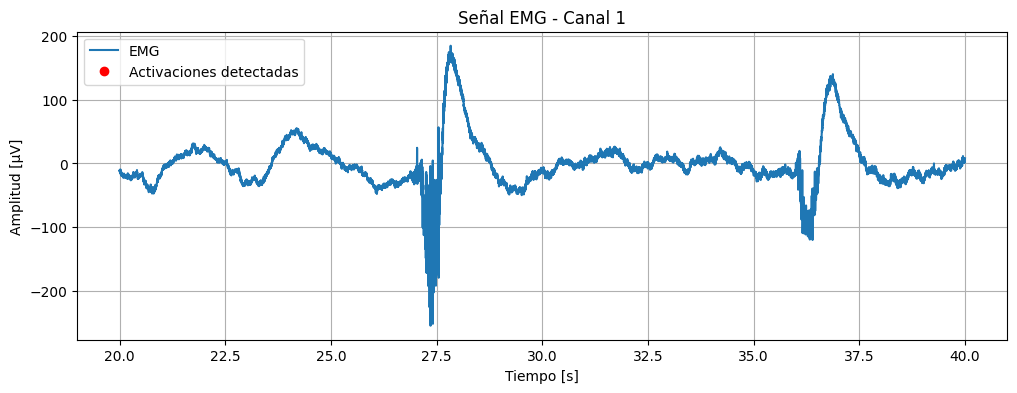

In [151]:
emg.plot_activaciones(canal="1",start_time=20, end_time=40)

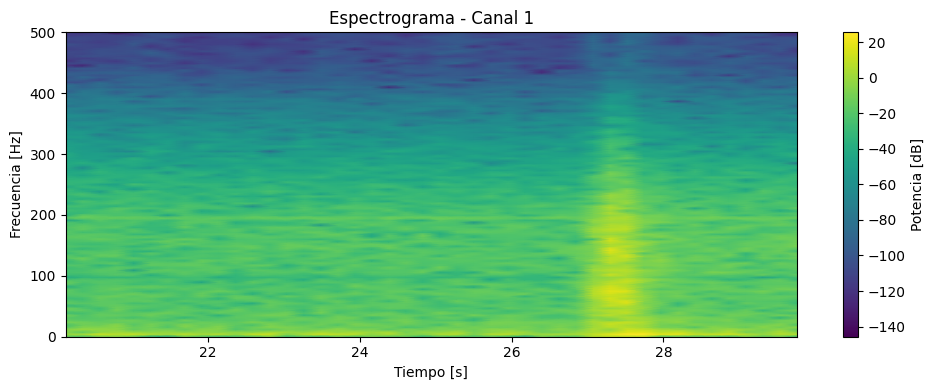

In [152]:
emg.plot_spectrogram(canal="1", start_time=20, end_time=30)

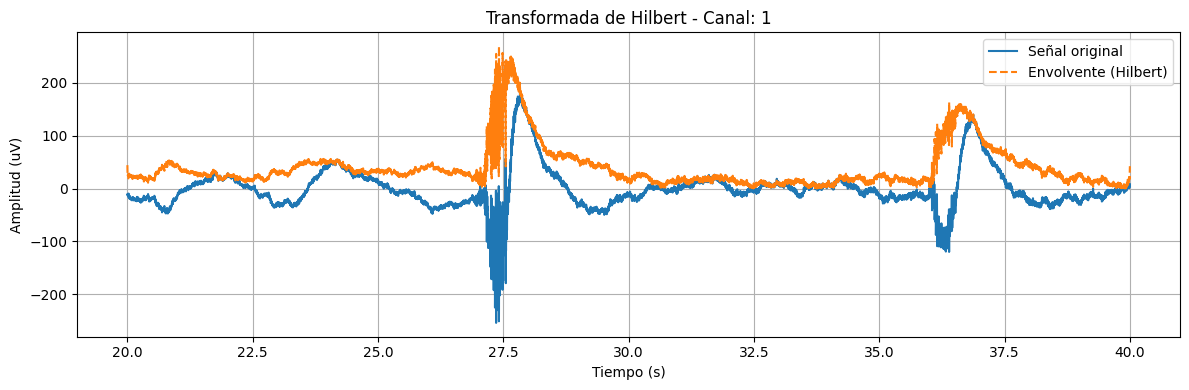

array([[-11.89746094+42.76091294j, -12.64697266+30.02079352j,
        -12.37353516+29.16542015j, ...,   7.36816406+29.17133774j,
          7.11865234+28.83525796j,   8.06201172+41.66475703j]])

In [153]:
emg.plot_hilbert(picks=["1"], tmin=20, tmax= 40)

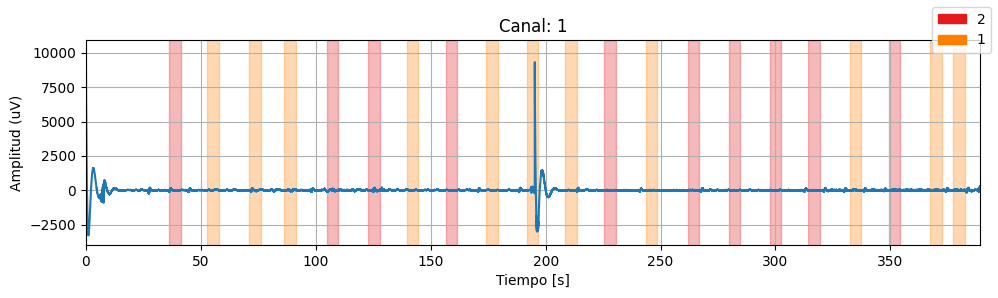

In [154]:
emg.plot(show_anotaciones=True)